['S5', 'S6']
[13, 15]
[['R0', 'S0', 'S6'], ['R0', 'S1', 'S6'], ['R0', 'S2', 'S6'], ['R0', 'S3', 'S6'], ['R0', 'S4', 'S6']]
5
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'R0+S2s -> R0+S2', 'R0+S3s -> R0+S3', 'R0+S4s -> R0+S4', 'R1+S0s -> R1+S0', 'R1+S1s -> R1+S1', 'R1+S2s -> R1+S2', 'R1+S3s -> R1+S3', 'R1+S4s -> R1+S4', 'S0+S5s -> S0+S5', 'S0+S6s -> S0+S6', 'S1+S5s -> S1+S5', 'S1+S6s -> S1+S6', 'S2+S5s -> S2+S5', 'S2+S6s -> S2+S6', 'S3+S5s -> S3+S5', 'S3+S6s -> S3+S6', 'S4+S5s -> S4+S5', 'S4+S6s -> S4+S6', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'S4s -> S4', 'S5s -> S5', 'S6s -> S6']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.

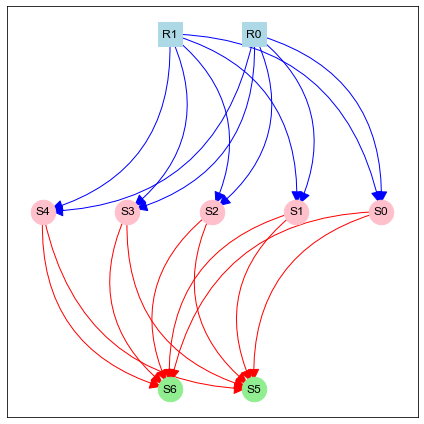

In [1]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time

# --- Example usage with new class structure ---
seed = 52
np.random.seed(seed)
random.seed(seed)

NR = 2

NS_vec = [5,2]
NS = sum(NS_vec)
p_f = 0.75
p_r = 0
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS-2}', f'S{NS-1}']
print(target_nodes)

# species_names, reaction_strings, L, input_indices = generate_random_signaling_network(NR, NL, NL_in, prob, include_reverse=True, include_uncatalyzed=True)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

target_node_idxs = [species_names.index(node) for node in target_nodes]
print(target_node_idxs)
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(n_paths)
print(len(n_paths))
#print(input_indices)
print(reaction_strings)

# n_nodes = 3
# NS = 1
# prob = 1
# extra_reactions = ['A+B -> C+C']
# input_reactions_list = [['R0+A -> R0+B']]
# species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
# #visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)

print(L)
print(reaction_strings)

# NR = 1
# NL_vec = [2,2]
# species_names, reaction_strings, L = generate_feedforward_signaling_network(NR, NL_vec)

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", r_n.n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - r_n.n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()


cycles = compute_cycles(r_n)

# # Visualize linkage classes
# sz = 3
# fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

# if len(r_n.linkage_groups) == 1:
#     pos = nx.spring_layout(r_n.linkage_groups[0])
#     nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#     axes.set_title("Linkage class 1")
# else:
#     for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
#         pos = nx.spring_layout(G)
#         nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
#         ax.set_title(f"Linkage class {i+1}")
# plt.tight_layout()
# plt.show()

# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)



rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


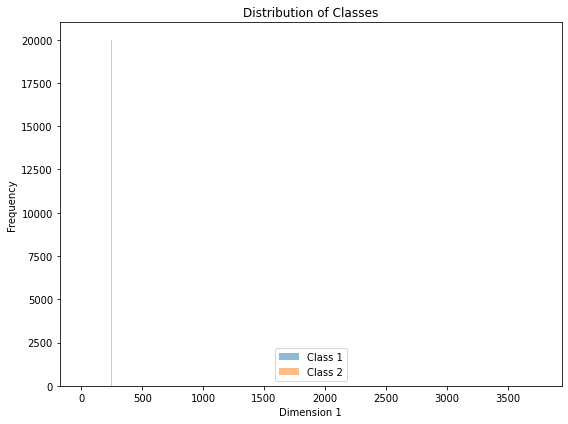

In [20]:
############################################################
################  Load classification data #################
############################################################

n_classes = 2

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

data_type = "gaussians"
n_samples = 20000

if data_type == "gaussian":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1 = scale*7.5e0 * np.ones(input_dim)
    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1 = np.abs(np.random.multivariate_normal(mu_1, cov_1, n_samples))

    mu_2 = scale*1e0 * np.ones(input_dim)
    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "gaussians":
######  Gaussian example
    
    input_dim = 1
    scale = 5

    mu_1a = scale*2.5e0 * np.ones(input_dim)
    mu_1b = scale*7.5e2 * np.ones(input_dim)

    cov_1 = scale**1 * 0.02 * np.diag(np.ones(input_dim))
    dist_1a = np.abs(np.random.multivariate_normal(mu_1a, cov_1, int(n_samples)))
    dist_1b = np.abs(np.random.multivariate_normal(mu_1b, cov_1, int(n_samples)))
    dist_1 = np.concatenate([dist_1a, dist_1b], axis=0)

    mu_2 = scale*5e1 * np.ones(input_dim)

    cov_2 = scale**1 *0.02 * np.diag(np.ones(input_dim))
    dist_2 = np.abs(np.random.multivariate_normal(mu_2, cov_2, n_samples))

    data_list = [[dat for dat in dist_1], [dat for dat in dist_2]]

elif data_type == "moons":
    # Convert sklearn noisy_moons to same format as data_list,
    # allowing user to specify scale and offset
    noisy_moons_X, noisy_moons_y = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)

    # Specify the desired scale and offset here
    noisy_moons_scale = 10.0    # Change to your desired scale
    noisy_moons_offset = noisy_moons_scale * np.array([2.0, 2.0])  # Change for desired offset; must have shape (2,)

    # Apply scale and offset
    noisy_moons_X = noisy_moons_X * noisy_moons_scale + noisy_moons_offset
    data_list = [[dat for dat in noisy_moons_X[noisy_moons_y == i]] for i in range(2)]

elif data_type == "circle_vs_square":
    # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
    # Class 0: Points inside circle centered at (x_c, x_c) with radius r
    # Class 1: Points outside the circle
    scale = 1
    offset = scale * 0.0
    x_c = scale * 5.0 + offset     # center coordinate
    r = scale * 3.0         # radius of circle
    
    dist_circle = []  # class 0: inside circle
    dist_square = []  # class 1: outside circle
    
    for _ in range(n_samples):
        # Sample uniformly from square [0, 2*x_c] x [0, 2*x_c]
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset
        
        # Check if point is inside circle
        dist_from_center = np.sqrt((x - x_c)**2 + (y - x_c)**2)
        
        if dist_from_center <= r:
            dist_circle.append(np.array([x, y]))
        else:
            dist_square.append(np.array([x, y]))
    
    data_list = [dist_circle, dist_square]

elif data_type == "diagonal_cut":
    # Classify according to which side of the diagonal y = x the point is on
    # Class 0: y > x; Class 1: y <= x
    scale = 0.2
    offset = scale * 2.0
    x_c = scale * 5.0 + offset  # to keep square region similar to above
    dist_above = []   # class 0: y > x
    dist_below = []   # class 1: y <= x

    for _ in range(n_samples):
        x = np.random.uniform(0, 2 * (x_c - offset)) + offset
        y = np.random.uniform(0, 2 * (x_c - offset)) + offset

        if y > x:
            dist_above.append(np.array([x, y]))
        else:
            dist_below.append(np.array([x, y]))
    
    data_list = [dist_above, dist_below]

elif data_type == "bottom_quarter_intersect":
    # Class 0: Points in the bottom quarter region defined by the intersection of y = x and y = 1 - x
    # inside the square [0, 1] x [0, 1], then apply scale and offset
    # Class 1: All other points inside the [0, 1] x [0, 1] square, excluding class 0.
    # That region is the triangle below both lines: y <= x AND y <= 1 - x. This triangle's vertices are: (0,0), (0.5,0), (1,0)
    dist_bottom_quarter = []  # class 0
    dist_other = []           # class 1
    
    scale = 10
    offset = scale * 0.0

    for _ in range(n_samples):
        # generate point in [0,1]x[0,1]
        x = np.random.uniform(0, 1)
        y = np.random.uniform(0, 1)

        # Triangle: y <= x AND y <= 1-x
        if y <= x and y <= 1 - x:
            # Apply scale and offset before adding
            p = np.array([x, y]) * scale + offset
            dist_bottom_quarter.append(p)
        else:
            p = np.array([x, y]) * scale + offset
            dist_other.append(p)

    data_list = [dist_bottom_quarter, dist_other]


input_data = InputData(n_classes, data_list)

# Redefine dist_1 and dist_2 from data_list for legacy code compatibility, but now as np.arrays
dist_1 = np.vstack(data_list[0])
dist_2 = np.vstack(data_list[1])

plt.figure(figsize=(8, 6))
if dist_1.shape[1] == 1:
    # Use fixed-width bins based on the min/max over both classes
    all_x = np.concatenate([dist_1[:, 0], dist_2[:, 0]])
    bin_width = 5  # Set desired bin width here
    bins = np.arange(np.min(all_x), np.max(all_x) + bin_width, bin_width)
    plt.hist(dist_1[:, 0], bins=bins, alpha=0.5, label='Class 1')
    plt.hist(dist_2[:, 0], bins=bins, alpha=0.5, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Frequency')
elif dist_1.shape[1] == 2:
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
else:
    # More than 2 dimensions: project to first two
    plt.scatter(dist_1[:, 0], dist_1[:, 1], alpha=0.3, s=1, label='Class 1')
    plt.scatter(dist_2[:, 0], dist_2[:, 1], alpha=0.3, s=1, label='Class 2')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
plt.title('Distribution of Classes')
plt.legend()
plt.tight_layout()
plt.show()



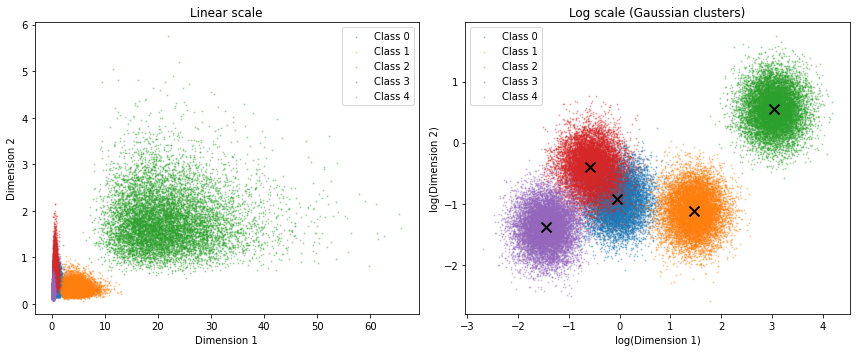

In [3]:
import numpy as np

def generate_lognormal_mixture(
    n_classes: int,
    n_samples_per_class: int,
    input_dim: int,
    log_means: list,
    log_variances: list,
    random_state: int = None
):
    if random_state is not None:
        np.random.seed(random_state)
    
    data_list = []
    for c in range(n_classes):
        mu = np.array(log_means[c]).flatten()
        var = log_variances[c]
        if np.isscalar(var):
            cov = var * np.eye(input_dim)
        else:
            cov = np.diag(np.array(var).flatten())
        
        log_samples = np.random.multivariate_normal(mu, cov, n_samples_per_class)
        samples = np.exp(log_samples)
        data_list.append([sample for sample in samples])
    
    return n_classes, data_list


def generate_lognormal_mixture_random_centers(
    n_classes: int,
    n_samples_per_class: int,
    input_dim: int = 1,
    center_variance: float = 1.0,
    log_variance: float = 0.3,
    center_offset: float = 3.0,
    random_state: int = None
):
    """
    Both center_variance and log_variance are TOTAL variances.
    They are divided by input_dim to get per-dimension variance,
    ensuring comparable spread across different dimensionalities.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Scale both by dimension for comparable total variance
    per_dim_center_variance = center_variance / input_dim
    per_dim_log_variance = log_variance / input_dim
    
    log_means = []
    for c in range(n_classes):
        center = np.random.normal(0, np.sqrt(per_dim_center_variance), size=input_dim)
        log_mean = center + center_offset
        log_means.append(log_mean)
    
    log_variances = [per_dim_log_variance] * n_classes
    
    n_classes_out, data_list = generate_lognormal_mixture(
        n_classes=n_classes,
        n_samples_per_class=n_samples_per_class,
        input_dim=input_dim,
        log_means=log_means,
        log_variances=log_variances,
        random_state=None
    )
    
    return n_classes_out, data_list, log_means


def project_data_list(data_list, d):

    projected_data_list = []
    for class_data in data_list:
        projected_class = [sample[:d] for sample in class_data]
        projected_data_list.append(projected_class)
    return projected_data_list


n_classes = 5
input_dim = 10
center_variance = 20.0
log_variance = 1
proj_dim = 6
NR = proj_dim

# Generate 3 classes with random centers in 2D
n_classes, data_list, log_means = generate_lognormal_mixture_random_centers(
    n_classes=n_classes,
    n_samples_per_class=10000,
    input_dim=input_dim,
    center_variance=center_variance,   # Total variance spread across dimensions
    log_variance=log_variance,      # How tight each class cluster is
    center_offset=0.0,     # Shift so medians are around exp(4) ≈ 55
    random_state=402
)


data_list = project_data_list(data_list, d=proj_dim)
input_data = InputData(n_classes, data_list)


# Visualize (2D case)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    plt.scatter(arr[:, 0], arr[:, 1], alpha=0.3, s=1, label=f'Class {c}')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Linear scale')
plt.legend()

plt.subplot(1, 2, 2)
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    plt.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
# Plot the centers
for i, lm in enumerate(log_means):
    plt.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
plt.xlabel('log(Dimension 1)')
plt.ylabel('log(Dimension 2)')
plt.title('Log scale (Gaussian clusters)')
plt.legend()

plt.tight_layout()
plt.show()

['S5', 'S6', 'S7', 'S8', 'S9']


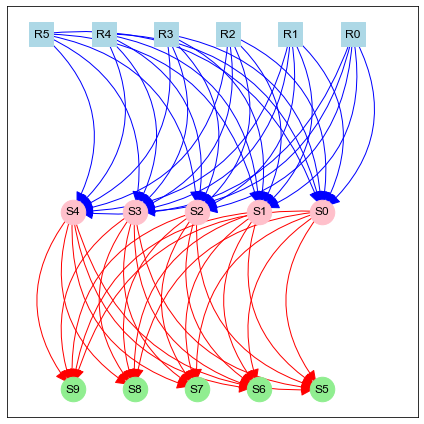

In [13]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

from scipy.integrate import solve_ivp
from functools import partial
import time


#NR = proj_dim

NS_vec = [5,n_classes]
NS = sum(NS_vec)
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS - n_classes + i}' for i in range(n_classes)]
print(target_nodes)
p_r = 0.0

species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)
target_node_idxs = [species_names.index(node) for node in target_nodes]

visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')


r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
sim.solve_conservation_laws()
rates_orig = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])


Starting CRN (graph) training: 100 batches, batch_size=20
Batch    0/100 | Loss: 3.0456 (avg: 3.0456) | Acc: 20.0% (avg: 20.0%) | log_ra:1.24e+00 | Rates: [6.76e-02, 1.25e+01]
Batch   50/100 | Loss: 1.6232 (avg: 2.0776) | Acc: 40.0% (avg: 34.5%) | log_ra:1.35e+00 | Rates: [9.04e-02, 1.66e+01]
Batch   99/100 | Loss: 1.0581 (avg: 1.6772) | Acc: 80.0% (avg: 50.6%) | log_ra:1.44e+00 | Rates: [6.14e-02, 1.87e+01]

Training Summary
Training time: 12.6 seconds
Final loss (last 100 batches): 1.6772
Min loss achieved: 1.0562
Final accuracy (last 100 batches): 50.6%
Best accuracy: 95.0%
Final param range: [6.14e-02, 1.87e+01], mean: 1.93e+00


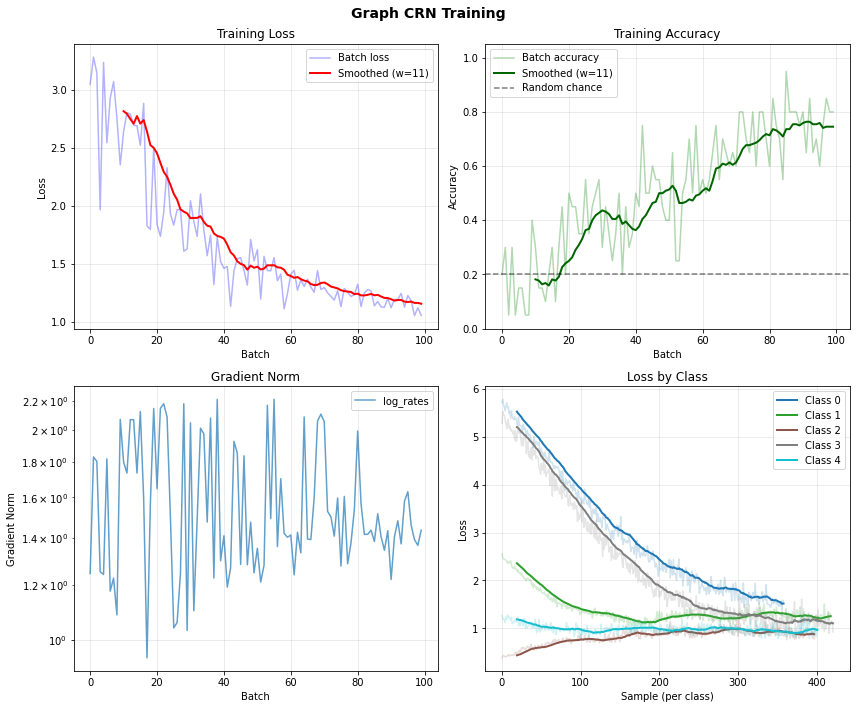

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [10]:
import numpy as np
from CRNs.training import GraphComputation, CRNModel, UnifiedTrainer, run_training_crn, plot_training_diagnostics

# ============== SETUP ==============
# Assumes already defined: 
#   r_n, sim, L, G, input_nodes, target_nodes, n_classes, input_data
#   dR_dC_func, dR_dk_func, dR_dl_func, generate_positive_initial_concentrations_nnls

# Initialize rates (log-normal)
n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 1.0)
r_n.update_rates(rates)

# ============== GRAPH COMPUTATION ==============
graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)

# Build l0 to match graph node ordering
n_nodes = len(graph_comp.nodes)
default_l0 = np.ones(n_nodes)

# Target node indices in species list
target_node_idxs = [r_n.species_names.index(node) for node in target_nodes]
n_inputs = len(input_nodes)

# ============== MODEL ==============
crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=n_inputs,
    default_l0=default_l0,
    forward_method='graph',
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

# ============== TRAINER ==============
trainer = UnifiedTrainer(
    crn_model,
    optimizer_type='adam',
    lr_dict={'log_rates': 0.001, 'log_l0': 0.001},
    max_grad_norm=50.0,
    frozen_params=['log_l0']
)

# ============== TRAIN ==============
history = run_training_crn(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=100,
    batch_size=20,
    T_start=0.1,
    T_end=0.1,
    T_decay=0.99,
    noise_start=0.0,
    noise_end=0.0,
    noise_decay=0.99,
    print_every=50
)

plot_training_diagnostics(history, title="Graph CRN Training")

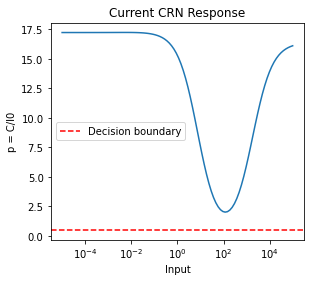

In [ ]:
from CRNs.training import (SimpleMLP, MLPModel, UnifiedTrainer, 
                           TrainingHistory, run_training, plot_training_diagnostics)

# Setup
mlp = SimpleMLP([NR, 6, n_classes], activation='tanh')
model = MLPModel(mlp, n_classes=n_classes)
trainer = UnifiedTrainer(model, lr=0.01, max_grad_norm=50.0)

# Run training in one line!
history = run_training(
    trainer=trainer,
    input_data=input_data,
    n_classes=n_classes,
    num_batches=100,
    batch_size=20,
    T_start=0.5, T_end=0.0, T_decay=0.99,
    noise_start=0.0, noise_end=0.0, noise_decay=0.9,
    print_every=50
)

# Plot results
plot_training_diagnostics(history, title="MLP Training", max_grad_norm=50.0, smoothing_window=1)

In [5]:
from CRNs import *
from CRNs.training import (
    GraphComputation, CRNModel, UnifiedTrainer, 
    run_training_crn_multitask, plot_training_diagnostics,
    generate_multitask_data, MultiTaskInputData
)
import numpy as np
import matplotlib.pyplot as plt
import random

# ============== PARAMETERS ==============
seed = 402
n_classes = 5
input_dim = 10
center_variance = 20.0
log_variance = 1
proj_dim = 6
NR = proj_dim
hidden_dim = 5
n_tasks = 2

np.random.seed(seed)
random.seed(seed)

Target nodes: ['S5', 'S6', 'S7', 'S8', 'S9']
Number of paths: [['R0', 'S0', 'S9'], ['R0', 'S1', 'S9'], ['R0', 'S2', 'S9'], ['R0', 'S3', 'S9'], ['R0', 'S4', 'S9']]


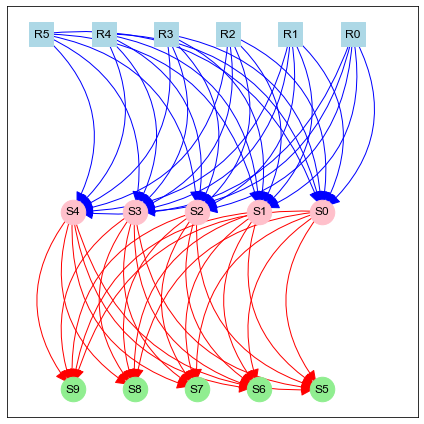

In [6]:
# ============== NETWORK STRUCTURE ==============
NS_vec = [hidden_dim, n_classes]
NS = sum(NS_vec)
input_nodes = [f'R{i}' for i in range(NR)]
target_nodes = [f'S{NS - n_classes + i}' for i in range(n_classes)]
print(f"Target nodes: {target_nodes}")
p_r = 0.0

species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = \
    generate_layered_feedforward_signaling_network(
        NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True
    )
target_node_idxs = [species_names.index(node) for node in target_nodes]

visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=NS_vec[-1])
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(f"Number of paths: {n_paths}")

# Create reaction network
r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=seed,
    species_names=species_names,
    force_reverse=True
)

# Create simulator and derivatives
sim = ReactionNetworkSimulator(r_n)
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
sim.solve_conservation_laws()

In [7]:
# ============== GRAPH COMPUTATION ==============
# Initialize rates
n_rates = len(r_n.get_rates())
rates = np.exp(np.random.randn(n_rates) * 1.0)
r_n.update_rates(rates)

graph_comp = GraphComputation(G, input_nodes, target_nodes)
graph_comp.build_r_n_maps(r_n)
n_nodes = len(graph_comp.nodes)
n_inputs = len(input_nodes)

# ============== GENERATE MULTI-TASK DATA ==============
multi_task_data = generate_multitask_data(
    n_tasks=n_tasks,
    n_classes=n_classes,
    n_samples_per_class=10000,
    input_dim=input_dim,
    proj_dim=proj_dim,
    center_variance=center_variance,
    log_variance=log_variance,
    center_offset=0.0,
    n_nodes=n_nodes,
    NR=NR,
    hidden_dim=hidden_dim,
    input_data_class=InputData,
    l0_log_mean=0.0,
    l0_log_std=5.0,
    base_seed=seed
)

print(f"Generated {multi_task_data.n_tasks} tasks")
for task_id in multi_task_data.task_ids:
    l0 = multi_task_data.get_l0(task_id)
    internal_l0 = l0[NR:NR+hidden_dim]
    print(f"  {task_id}: internal l0 = {internal_l0}")

Generated 2 tasks
  task_0: internal l0 = [2.90319623e+02 1.88130493e+03 2.92843740e-03 1.81895829e-01
 1.06544452e+00]
  task_1: internal l0 = [3.08318302e+01 8.88531481e-02 5.05977645e-01 1.31516889e+01
 2.93754978e-06]


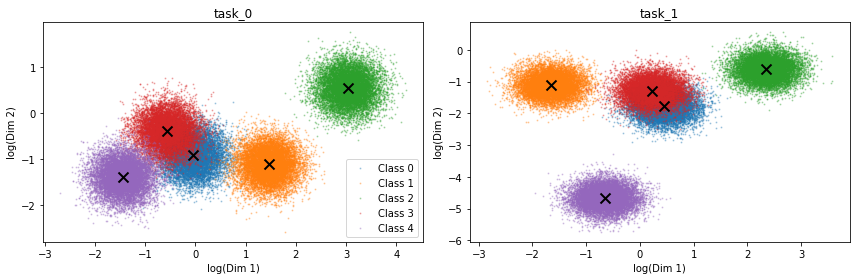

In [8]:
# ============== VISUALIZE TASK DATA ==============
fig, axes = plt.subplots(1, min(n_tasks, 3), figsize=(12, 4))
if n_tasks == 1:
    axes = [axes]

for i, task_id in enumerate(multi_task_data.task_ids[:3]):
    task = multi_task_data.get_task(task_id)
    data_list = [task['input_data'].data_list[c] for c in range(n_classes)]
    
    ax = axes[i]
    for c, class_data in enumerate(data_list):
        arr = np.vstack(class_data)
        ax.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
    
    # Plot centers
    for lm in task['log_means']:
        ax.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
    
    ax.set_xlabel('log(Dim 1)')
    ax.set_ylabel('log(Dim 2)')
    ax.set_title(f'{task_id}')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

Trainable params: ['log_rates']
Starting CRN (graph) multi-task training: 1000 batches, batch_size=20, n_tasks=2
Batch    0/1000 | Loss: 3.4367 (avg: 3.4367) | Acc: 30.0% (avg: 30.0%) | log_ra:2.62e+00 | Rates: [9.58e-02, 1.21e+01]
Batch  100/1000 | Loss: 1.6861 (avg: 2.3757) | Acc: 15.0% (avg: 23.7%) | log_ra:2.75e+00 | Rates: [5.50e-02, 3.68e+01]
Batch  200/1000 | Loss: 1.4324 (avg: 1.4606) | Acc: 30.0% (avg: 41.4%) | log_ra:2.44e+00 | Rates: [5.24e-02, 6.63e+01]
Batch  300/1000 | Loss: 1.0714 (avg: 1.1992) | Acc: 70.0% (avg: 61.1%) | log_ra:2.47e+00 | Rates: [2.98e-02, 1.68e+02]
Batch  400/1000 | Loss: 0.9742 (avg: 0.9635) | Acc: 75.0% (avg: 74.2%) | log_ra:1.99e+00 | Rates: [1.76e-02, 3.66e+02]
Batch  500/1000 | Loss: 0.6384 (avg: 0.7693) | Acc: 65.0% (avg: 75.5%) | log_ra:4.71e-01 | Rates: [1.10e-02, 6.16e+02]
Batch  600/1000 | Loss: 0.4522 (avg: 0.6808) | Acc: 90.0% (avg: 79.8%) | log_ra:5.33e-01 | Rates: [7.38e-03, 9.63e+02]
Batch  700/1000 | Loss: 0.5620 (avg: 0.5771) | Acc: 85

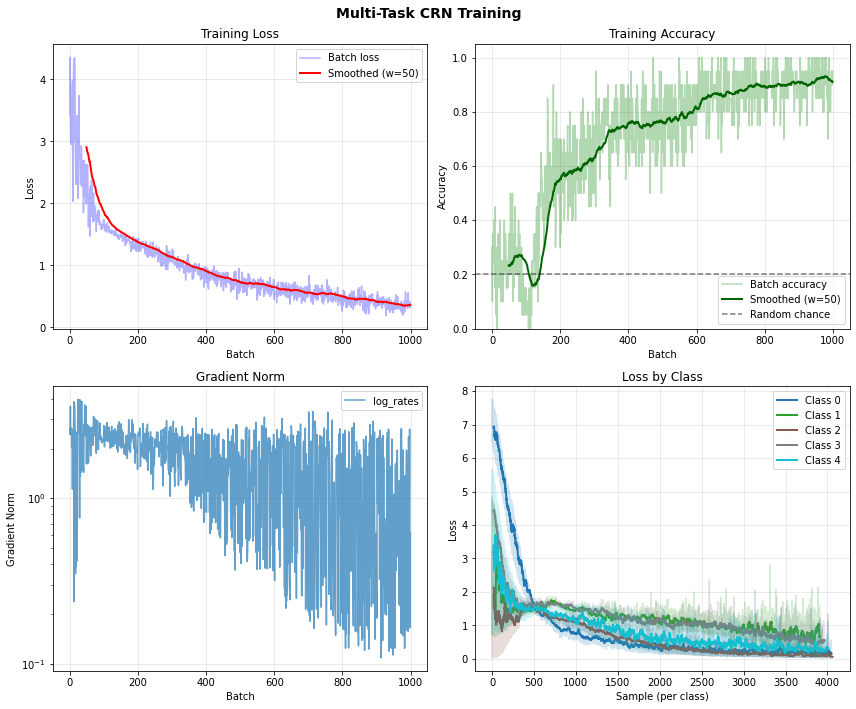

(<Figure size 864x720 with 4 Axes>,
 array([<Axes: title={'center': 'Training Loss'}, xlabel='Batch', ylabel='Loss'>,
        <Axes: title={'center': 'Training Accuracy'}, xlabel='Batch', ylabel='Accuracy'>,
        <Axes: title={'center': 'Gradient Norm'}, xlabel='Batch', ylabel='Gradient Norm'>,
        <Axes: title={'center': 'Loss by Class'}, xlabel='Sample (per class)', ylabel='Loss'>],
       dtype=object))

In [9]:
# ============== MODEL ==============
# Use first task's l0 as initial default (will be overwritten during training)
default_l0 = multi_task_data.get_l0(multi_task_data.task_ids[0]).copy()

crn_model = CRNModel(
    r_n=r_n,
    sim=sim,
    L=L,
    class_ids=target_node_idxs,
    n_inputs=n_inputs,
    default_l0=default_l0,
    forward_method='graph',
    graph_comp=graph_comp,
    dR_dC_func=dR_dC_func,
    dR_dk_func=dR_dk_func,
    dR_dl_func=dR_dl_func,
    generate_init_func=generate_positive_initial_concentrations_nnls,
)

# ============== TRAINER (with frozen l0) ==============
trainer = UnifiedTrainer(
    crn_model,
    optimizer_type='adam',
    lr_dict={'log_rates': 0.001},
    max_grad_norm=50.0,
    frozen_params=['log_l0']  # Freeze l0 - it's set per-task
)

print(f"Trainable params: {trainer.get_trainable_params()}")


# ============== TRAIN MULTI-TASK ==============
history = run_training_crn_multitask(
    trainer=trainer,
    multi_task_data=multi_task_data,
    n_classes=n_classes,
    num_batches=1000,
    batch_size=20,
    T_start=0.1,
    T_end=0.1,
    T_decay=0.99,
    noise_start=0.0,
    noise_end=0.0,
    noise_decay=0.99,
    print_every=100
)

plot_training_diagnostics(history, title="Multi-Task CRN Training")

In [ ]:
# ============== EVALUATE PER-TASK ==============
def evaluate_task(trainer, task_id, multi_task_data, n_samples=500, temperature=0.1):
    """Evaluate accuracy on a specific task."""
    # Set l0 for this task
    trainer.model._default_l0 = multi_task_data.get_l0(task_id).copy()
    
    correct = 0
    n_classes = multi_task_data.get_n_classes(task_id)
    
    for _ in range(n_samples):
        target_idx = random.randrange(n_classes)
        inputs = multi_task_data.get_next_training_sample(task_id, target_idx)
        
        outputs = trainer.model.forward(inputs)
        probs = trainer.softmax(outputs, temperature)
        
        if np.argmax(probs) == target_idx:
            correct += 1
    
    return correct / n_samples

print("Per-task accuracy:")
for task_id in multi_task_data.task_ids:
    acc = evaluate_task(trainer, task_id, multi_task_data, n_samples=500)
    print(f"  {task_id}: {acc:.1%}")